In [ ]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import shap
from scipy.sparse import hstack, csr_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack
import matplotlib as mpl
from matplotlib import font_manager
import lightgbm as lgb
import warnings
import math
import os
import re
import json
import numpy as np


from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
data_path = f'/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/{dataset}'
# data_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)

# 注册中文字体到matplotlib
font_path = "/System/Library/Fonts/Supplemental/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

matplotlib 识别的字体名: Songti SC


In [70]:
# 提取当前数据集的数字
def extract_integers(s: str):
    """
    从字符串中提取所有整数，返回一个 int 列表
    """
    return list(map(int, re.findall(r"\d+", s)))


In [71]:
def label_encoding(filtered_df, data_path):
    columns_to_change1 = [item for item in filtered_df if item.endswith('_定性')]
    columns_to_change2 = [item for item in filtered_df if item.endswith('_描述性')]

    # 对每个object类型的列进行Label Encoding
    object_columns = columns_to_change1+columns_to_change2
    if 'filtered_patient1' in data_path or 'filtered_patient2' in data_path or 'filtered_patient5' in data_path:
        object_columns.remove('脑脊液_透明度_描述性')
        object_columns.remove('脑脊液_蛋白定性_定性')

    features_to_change = [ '血_抗双链DNA抗体_定性', '血_抗核抗体_定性', '血_抗胞浆型中性粒细胞抗体_定性', '血_抗核周型中性粒细胞抗体_定性', '血_梅毒非特异性抗体_定性', '血_梅毒螺旋体抗体_定性',
                        '血_人类免疫缺陷病毒抗体_定性', '血_不规则抗体_定性', '血_直接抗人球蛋白试验_定性', '血_结核感染T细胞检测_定性', '血_人类免疫缺陷病毒P24抗原_定性', '血_M蛋白_描述性']

    if 'filtered_patient2' in data_path or 'filtered_patient4' in data_path:
        for i in features_to_change:
            object_columns.remove(i)

    le_dict = {}
    for col in object_columns:
        le = LabelEncoder()
        # 处理空值：先用'unknown'填充，再进行编码
        filtered_df[col] = filtered_df[col].fillna('unknown')
        filtered_df[col] = le.fit_transform(filtered_df[col].astype(str))  # 确保没有NaN，否则会报错
        le_dict[col] = le  # 保存编码器，后续可能用于推理
    
    return filtered_df
    

In [72]:

# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names

    
    # filtered_df.columns = clean_feature_names_simple(filtered_df.columns)
    # print("清洗后的列名:", filtered_df.columns.tolist())



In [73]:

# 自定义 Transformer：提取 XGBoost 叶子索引 → OneHot → 拼接
class XGBLeafTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, xgb_params=None, imputer=None):
        self.xgb_params = xgb_params if xgb_params is not None else {}
        self.imputer = imputer if imputer is not None else KNNImputer(n_neighbors=5)
        self.encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
        self.xgb_model = None

    def fit(self, X, y=None):
        self.xgb_model = xgb.XGBClassifier(**self.xgb_params, missing=np.nan)
        self.xgb_model.fit(X, y)

        leaf_index = self.xgb_model.apply(X)
        self.encoder.fit(leaf_index)

        # self.imputer.fit(X)
        return self

    def transform(self, X):
        leaf_index = self.xgb_model.apply(X)
        X_leaves = self.encoder.transform(leaf_index)

        # X_filled = self.imputer.transform(X)

        # return hstack([csr_matrix(X_filled), X_leaves])
        return X_leaves
    

In [74]:
def tain_model(X_train, y_train, X_val, y_val, key):
    def objective(trial):
        # 建议超参数范围
        xgb_params = {
            'n_estimators': trial.suggest_int('n_estimators', 10, 300, step=10),
            'max_depth': trial.suggest_int('max_depth', 2, 10),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'random_state': 42,
            'eval_metric': ['auc', 'logloss']
            # 'scale_pos_weight':
        }
        
        lr_param_ = {
            "C": trial.suggest_float("C", 1e-3, 10.0, log=True),
            "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
            "solver": "liblinear",
            "class_weight": trial.suggest_categorical("class_weight", [None, 'balanced']),
            "max_iter": 1000,
            "random_state": 42,
        }

        # Pipeline
        model = Pipeline(steps=[
            ("xgb_leaf", XGBLeafTransformer(xgb_params=xgb_params)),
            ("lr", LogisticRegression(**lr_param_))
        ])

        # 交叉验证 AUC
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        auc_scores = cross_val_score(
            model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1
        )
        
        return 1 - auc_scores.mean()
    
    # 创建 Optuna 研究
    study = optuna.create_study(
        direction='minimize',  # 最小化目标函数 (1 - AUC)
        sampler=optuna.samplers.TPESampler(seed=42),
    )

    # 运行优化
    print("开始超参数优化...")
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    # 输出最佳结果
    print("\n优化完成!")
    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Best AUC: {1 - best_trial.value:.4f}")  # 转换回 AUC
    print("  Best params: ")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")
    
    best_xgb_params = {
        'n_estimators': study.best_params["n_estimators"],
        'max_depth': study.best_params["max_depth"],
        'learning_rate': study.best_params["learning_rate"],
        'subsample': study.best_params["subsample"],
        'colsample_bytree': study.best_params["colsample_bytree"],
        'reg_alpha': study.best_params["reg_alpha"],
        'reg_lambda': study.best_params["reg_lambda"],
        'min_child_weight': study.best_params["min_child_weight"],
        'gamma': study.best_params["gamma"],
        'random_state': 42,
        'eval_metric': ['auc', 'logloss']
    }
    best_lr_params = {
        "C": study.best_params["C"],
        "penalty": study.best_params["penalty"],
        "solver": "liblinear",
        "class_weight": study.best_params["class_weight"],
        "max_iter": 1000
    }

    # 使用最佳参数重新训练最终模型
    print("\n使用最佳参数训练最终模型...")


    final_pipeline = Pipeline(steps=[
        ("xgb_leaf", XGBLeafTransformer(xgb_params=best_xgb_params)),
        ("lr", LogisticRegression(**best_lr_params))
    ])
    final_pipeline.fit(X_train, y_train)

    return final_pipeline

    

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

def bootstrap_auc_ci(y_true, y_score, B=1000, seed=2025, return_distribution=False):
    """
    Bootstrap percentile CI for ROC-AUC with stratified resampling on the test set.
    y_true: 1D array of {0,1}
    y_score: 1D array of predicted probabilities for class 1
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # 原始整套测试集点估计
    auc_point = roc_auc_score(y_true, y_score)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n_pos, n_neg = len(pos_idx), len(neg_idx)

    aucs = np.empty(B, dtype=float)
    for b in range(B):
        # 分层有放回采样，保持类样本量不变
        boot_pos = rng.choice(pos_idx, size=n_pos, replace=True)
        boot_neg = rng.choice(neg_idx, size=n_neg, replace=True)
        boot_idx = np.concatenate([boot_pos, boot_neg])

        # 计算本次 AUC
        aucs[b] = roc_auc_score(y_true[boot_idx], y_score[boot_idx])

    # 百分位 CI
    lower, median, upper = np.percentile(aucs, [2.5, 50.0, 97.5])
    if return_distribution:
        return {"point": auc_point, "median": median, "ci95": (lower, upper), "all": aucs}
    else:
        return {"point": auc_point, "median": median, "ci95": (lower, upper)}



In [ ]:

# 在各个数据集上评估最终模型
def evaluate_model(model, X, y, dataset_name, key):
    # y_pred = model.predict(X)
    if isinstance(model, np.ndarray):
        y_pred_proba = model
    else:
        y_pred_proba = model.predict_proba(X)[:, 1]

    # 最佳阈值
    best_thresh, best_auc = 0.5, 0
    for thresh in np.arange(0.1, 0.65, 0.05):
        pred_val = (y_pred_proba > thresh).astype(int)
        f1 = roc_auc_score(y, pred_val)
        if f1 > best_auc:
            best_thresh, best_auc = thresh, f1
            
    if dataset_name != '挑选':
        print(f"最佳阈值: {best_thresh:.2f}，测试集最大auc: {best_auc:.4f}")

    y_pred = (y_pred_proba >= best_thresh).astype(int)
    
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred_proba)
    res_auc = bootstrap_auc_ci(y, y_pred_proba, B=1000, seed=2025)
    print(f"AUC = {res_auc['point']:.3f} "
        f"(95% CI {res_auc['ci95'][0]:.3f}–{res_auc['ci95'][1]:.3f})")

    # res_pr = bootstrap_prauc_ci(y_true_test, y_score_test, B=1000, seed=2025)
    # print(f"PR-AUC = {res_pr['point']:.3f} "
    #     f"(95% CI {res_pr['ci95'][0]:.3f}–{res_pr['ci95'][1]:.3f})")

    print(f"\n{dataset_name} 集评估结果:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'CI': (round(res_auc['ci95'][0],4),round(res_auc['ci95'][1],4))
    }


In [ ]:
def draw_result(y_val, y_test, val_results, test_results, key, current_dataset):

    # 绘制ROC曲线
    plt.figure(figsize=(10, 8))

    # 计算各数据集的ROC曲线
    fpr_val, tpr_val, thresholds = roc_curve(y_val, val_results['y_pred_proba'])
    fpr_test, tpr_test, thresholds = roc_curve(y_test, test_results['y_pred_proba'])

    pd.DataFrame({
        "fpr": fpr_test,
        "tpr": tpr_test,
        "threshold": thresholds  
    }).to_csv(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/ROC/LR+XGBoost3/{key}/Dataset{current_dataset}_roc_curve.csv", index=False)


    # 绘制ROC曲线
    plt.plot(fpr_val, tpr_val, color='blue', lw=2, 
            label=f'验证集 AUC = {val_results["auc"]:.4f}')
    plt.plot(fpr_test, tpr_test, color='red', lw=2, 
            label=f'测试集 AUC = {test_results["auc"]:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{key} - LR_XGBoost3 ROC曲线', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/LR_XGBoost5/ROC_AUC/Dataset{current_dataset}/{key}ROC-AUC.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

    model = key
    data_to_append = {'val_accuracy':round(val_results['accuracy'],4),'val_precision':round(val_results['precision'],4),'val_recall':round(val_results['recall'],4),'val_f1':round(val_results['f1'],4),'roc_auc_val':round(val_results['auc'],4),'val_CI':val_results['CI'],
                    'test_accuracy':round(test_results['accuracy'],4),'test_precision':round(test_results['precision'],4),'test_recall':round(test_results['recall'],4),'test_f1':round(test_results['f1'],4),'roc_auc_test':round(test_results['auc'],4),'test_CI':test_results['CI']}
    # JSON 文件路径
    json_file = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4/LR_XGBoost5_data.json"

    # 如果文件存在，先读取已有数组，否则初始化为空列表
    if os.path.exists(json_file):
        with open(json_file, "r", encoding="utf-8") as f:
            try:
                existing_data = json.load(f)
                if f'LR_XGBoost5_Dataset{current_dataset}' not in existing_data:
                    existing_data[f'LR_XGBoost5_Dataset{current_dataset}'] = {}
            except json.JSONDecodeError:
                existing_data = {f'LR_XGBoost5_Dataset{current_dataset}':{}}
    else:
        existing_data = {f'LR_XGBoost5_Dataset{current_dataset}':{}}

    # 追加新的数据
    existing_data[f'LR_XGBoost5_Dataset{current_dataset}'][model] = data_to_append

    # 写回 JSON 文件
    with open(json_file, "w", encoding="utf-8") as f:
        json.dump(existing_data, f, ensure_ascii=False, indent=4)



In [77]:

# data_path = '/Users/yanjieni/Desktop/脑脊液/naojiye/data/final_data/filtered_patient8.csv'

filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})
# print(filtered_df['血_乙型肝炎病毒核心抗体.IgM_定量'])

[I 2025-10-17 17:32:25,222] A new study created in memory with name: no-name-fa759873-bee3-4bf6-ba20-d75cfd19963d


开始超参数优化...


Best trial: 1. Best value: 0.162956:   2%|▏         | 2/100 [00:00<00:18,  5.42it/s]

[I 2025-10-17 17:32:25,491] Trial 0 finished with value: 0.16407050625128095 and parameters: {'n_estimators': 120, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044, 'C': 0.6796578090758157, 'penalty': 'l2', 'class_weight': None}. Best is trial 0 with value: 0.16407050625128095.
[I 2025-10-17 17:32:25,621] Trial 1 finished with value: 0.1629555236728839 and parameters: {'n_estimators': 60, 'max_depth': 3, 'learning_rate': 0.005670807781371429, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.7727780074568463, 'reg_alpha': 4.17890272377219e-06, 'reg_lambda': 0.0032112643094417484, 'min_child_weight': 2, 'gamma': 1.4607232426760908, 'C': 0.029204338471814112, 'penalty': 'l2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.1629555236728839.


Best trial: 1. Best value: 0.162956:   4%|▍         | 4/100 [00:00<00:15,  6.03it/s]

...

[I 2025-10-17 17:32:36,284] Trial 91 finished with value: 0.14946163831386217 and parameters: {'n_estimators': 60, 'max_depth': 4, 'learning_rate': 0.13262858960363638, 'subsample': 0.9345714084100417, 'colsample_bytree': 0.6841557647711525, 'reg_alpha': 3.872656755660896e-08, 'reg_lambda': 1.5802676086336103, 'min_child_weight': 2, 'gamma': 4.330066369073657, 'C': 0.010072787584475317, 'penalty': 'l2', 'class_weight': 'balanced'}. Best is trial 82 with value: 0.1433531461365034.
[I 2025-10-17 17:32:36,360] Trial 92 finished with value: 0.15252169160347062 and parameters: {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.07111326836156567, 'subsample': 0.9173138736818767, 'colsample_bytree': 0.6714458592017245, 'reg_alpha': 5.596768499563768e-08, 'reg_lambda': 9.56164772883824, 'min_child_weight': 2, 'gamma': 3.948317461949725, 'C': 0.03434917327264869, 'penalty': 'l2', 'class_weight': 'balanced'}. Best is trial 82 with value: 0.1433531461365034.
[I 2025-10-17 17:32:36,453] Trial

Best trial: 82. Best value: 0.143353:  97%|█████████▋| 97/100 [00:11<00:00, 12.02it/s]

[I 2025-10-17 17:32:36,539] Trial 94 finished with value: 0.1501701168272188 and parameters: {'n_estimators': 80, 'max_depth': 3, 'learning_rate': 0.1090544467238152, 'subsample': 0.951033516808351, 'colsample_bytree': 0.7414331731805249, 'reg_alpha': 6.865468744202622e-05, 'reg_lambda': 4.201413808421391, 'min_child_weight': 1, 'gamma': 4.802625150548367, 'C': 0.0077092412248014885, 'penalty': 'l2', 'class_weight': 'balanced'}. Best is trial 82 with value: 0.1433531461365034.
[I 2025-10-17 17:32:36,609] Trial 95 finished with value: 0.15468265354922472 and parameters: {'n_estimators': 40, 'max_depth': 2, 'learning_rate': 0.050927019028525214, 'subsample': 0.9695025691321938, 'colsample_bytree': 0.7519350668635614, 'reg_alpha': 8.89480249058228e-06, 'reg_lambda': 0.3745184078946865, 'min_child_weight': 3, 'gamma': 1.4890671675702287, 'C': 0.016599114270277642, 'penalty': 'l2', 'class_weight': 'balanced'}. Best is trial 82 with value: 0.1433531461365034.
[I 2025-10-17 17:32:36,677] Tria

Best trial: 82. Best value: 0.143353: 100%|██████████| 100/100 [00:11<00:00,  8.58it/s]


[I 2025-10-17 17:32:36,745] Trial 97 finished with value: 0.14487736558037856 and parameters: {'n_estimators': 50, 'max_depth': 6, 'learning_rate': 0.08449122826336178, 'subsample': 0.9200792794931724, 'colsample_bytree': 0.6252047086551905, 'reg_alpha': 1.673838765447722e-06, 'reg_lambda': 0.17600861781756297, 'min_child_weight': 2, 'gamma': 4.597997282533387, 'C': 0.023161292715977454, 'penalty': 'l2', 'class_weight': 'balanced'}. Best is trial 82 with value: 0.1433531461365034.
[I 2025-10-17 17:32:36,814] Trial 98 finished with value: 0.14824178451868553 and parameters: {'n_estimators': 30, 'max_depth': 5, 'learning_rate': 0.08302800940277724, 'subsample': 0.939207605982561, 'colsample_bytree': 0.6142695861711426, 'reg_alpha': 1.6985746320472443e-06, 'reg_lambda': 0.18702189066978708, 'min_child_weight': 1, 'gamma': 4.6469349429976, 'C': 0.030353832137805726, 'penalty': 'l2', 'class_weight': 'balanced'}. Best is trial 82 with value: 0.1433531461365034.
[I 2025-10-17 17:32:36,871] Tr

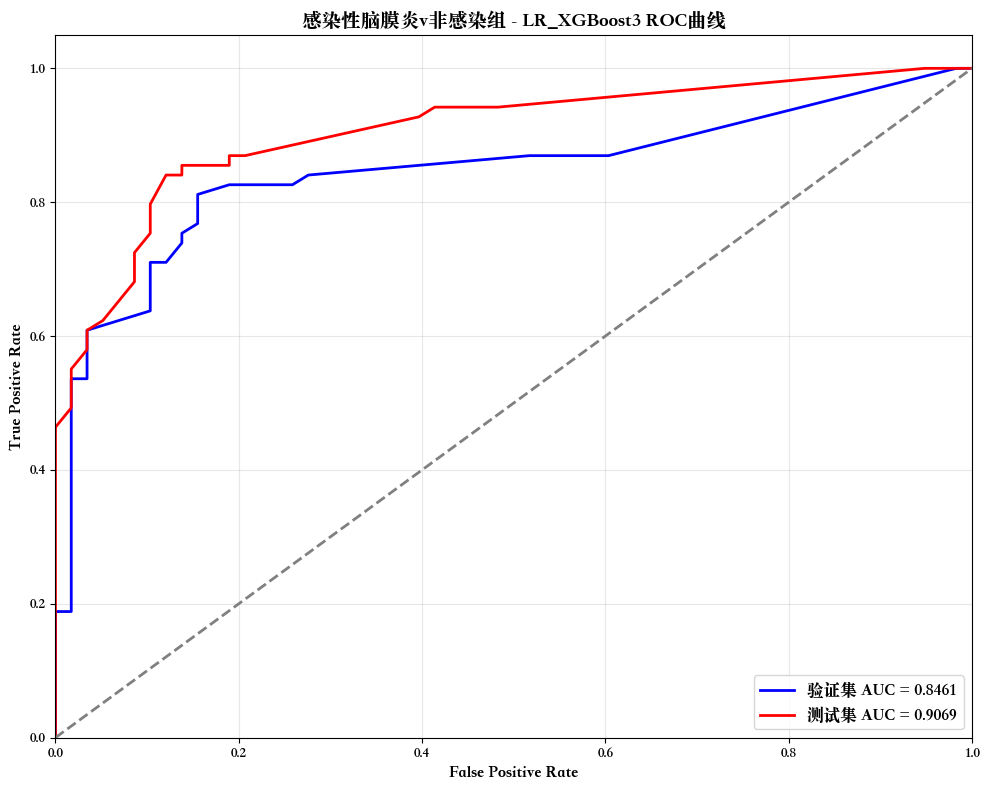

[I 2025-10-17 17:32:37,379] A new study created in memory with name: no-name-9c521e4f-8411-4d8e-8b89-4ee365a7ba6a


开始超参数优化...


Best trial: 1. Best value: 0.133139:   2%|▏         | 2/100 [00:00<00:06, 15.15it/s]

[I 2025-10-17 17:32:37,457] Trial 0 finished with value: 0.13526706137000255 and parameters: {'n_estimators': 120, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044, 'C': 0.6796578090758157, 'penalty': 'l2', 'class_weight': None}. Best is trial 0 with value: 0.13526706137000255.
[I 2025-10-17 17:32:37,512] Trial 1 finished with value: 0.13313916475681187 and parameters: {'n_estimators': 60, 'max_depth': 3, 'learning_rate': 0.005670807781371429, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.7727780074568463, 'reg_alpha': 4.17890272377219e-06, 'reg_lambda': 0.0032112643094417484, 'min_child_weight': 2, 'gamma': 1.4607232426760908, 'C': 0.029204338471814112, 'penalty': 'l2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.13313916475681187.


Best trial: 1. Best value: 0.133139:   4%|▍         | 4/100 [00:00<00:06, 15.41it/s]

...

[I 2025-10-17 17:32:53,998] Trial 95 finished with value: 0.07893111790170604 and parameters: {'n_estimators': 160, 'max_depth': 5, 'learning_rate': 0.05216557304843622, 'subsample': 0.7568550818925185, 'colsample_bytree': 0.9766490362044101, 'reg_alpha': 0.00020983376208468614, 'reg_lambda': 1.2484053579658965e-08, 'min_child_weight': 5, 'gamma': 2.219672465645519, 'C': 0.24977467453400368, 'penalty': 'l2', 'class_weight': None}. Best is trial 21 with value: 0.07350713012477728.
[I 2025-10-17 17:32:54,149] Trial 96 finished with value: 0.08140756302521002 and parameters: {'n_estimators': 180, 'max_depth': 5, 'learning_rate': 0.0947942558381145, 'subsample': 0.7548584566902227, 'colsample_bytree': 0.9956840755715132, 'reg_alpha': 8.654221751361564e-06, 'reg_lambda': 1.1875419836632251e-08, 'min_child_weight': 5, 'gamma': 2.2746683339914604, 'C': 0.26193752983432494, 'penalty': 'l2', 'class_weight': None}. Best is trial 21 with value: 0.07350713012477728.


Best trial: 21. Best value: 0.0735071:  99%|█████████▉| 99/100 [00:17<00:00,  5.93it/s]

[I 2025-10-17 17:32:54,306] Trial 97 finished with value: 0.09125923096511335 and parameters: {'n_estimators': 160, 'max_depth': 5, 'learning_rate': 0.054101072051024976, 'subsample': 0.7630135347172636, 'colsample_bytree': 0.9981692099243725, 'reg_alpha': 0.00023291872906025285, 'reg_lambda': 8.016766879308441e-08, 'min_child_weight': 4, 'gamma': 2.1459291337596964, 'C': 0.44122103851300837, 'penalty': 'l2', 'class_weight': None}. Best is trial 21 with value: 0.07350713012477728.
[I 2025-10-17 17:32:54,431] Trial 98 finished with value: 0.08317099567099562 and parameters: {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.051373137041193985, 'subsample': 0.7473161350225287, 'colsample_bytree': 0.9752020744355926, 'reg_alpha': 0.00011632217629950009, 'reg_lambda': 1.0243854635219545e-08, 'min_child_weight': 5, 'gamma': 1.9322056214253533, 'C': 0.1111657548574658, 'penalty': 'l2', 'class_weight': None}. Best is trial 21 with value: 0.07350713012477728.


Best trial: 21. Best value: 0.0735071: 100%|██████████| 100/100 [00:17<00:00,  5.82it/s]


[I 2025-10-17 17:32:54,571] Trial 99 finished with value: 0.07928444104914689 and parameters: {'n_estimators': 170, 'max_depth': 5, 'learning_rate': 0.0746208011224764, 'subsample': 0.7318733736944961, 'colsample_bytree': 0.8601914842328264, 'reg_alpha': 0.0033649506243180233, 'reg_lambda': 1.0797228320691893e-07, 'min_child_weight': 5, 'gamma': 2.4047856079060614, 'C': 0.16387991761937507, 'penalty': 'l2', 'class_weight': None}. Best is trial 21 with value: 0.07350713012477728.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.9265
  Best params: 
    n_estimators: 270
    max_depth: 6
    learning_rate: 0.03262691047413681
    subsample: 0.7302753997393214
    colsample_bytree: 0.9270053859931189
    reg_alpha: 2.2010756490506956e-07
    reg_lambda: 0.012968818098366863
    min_child_weight: 5
    gamma: 2.371962488588069
    C: 0.2736778061710166
    penalty: l2
    class_weight: None

使用最佳参数训练最终模型...
最佳阈值: 0.15，测试集最大auc: 0.7470

验证 集评估结果:
Accuracy: 0.8529
Precision: 

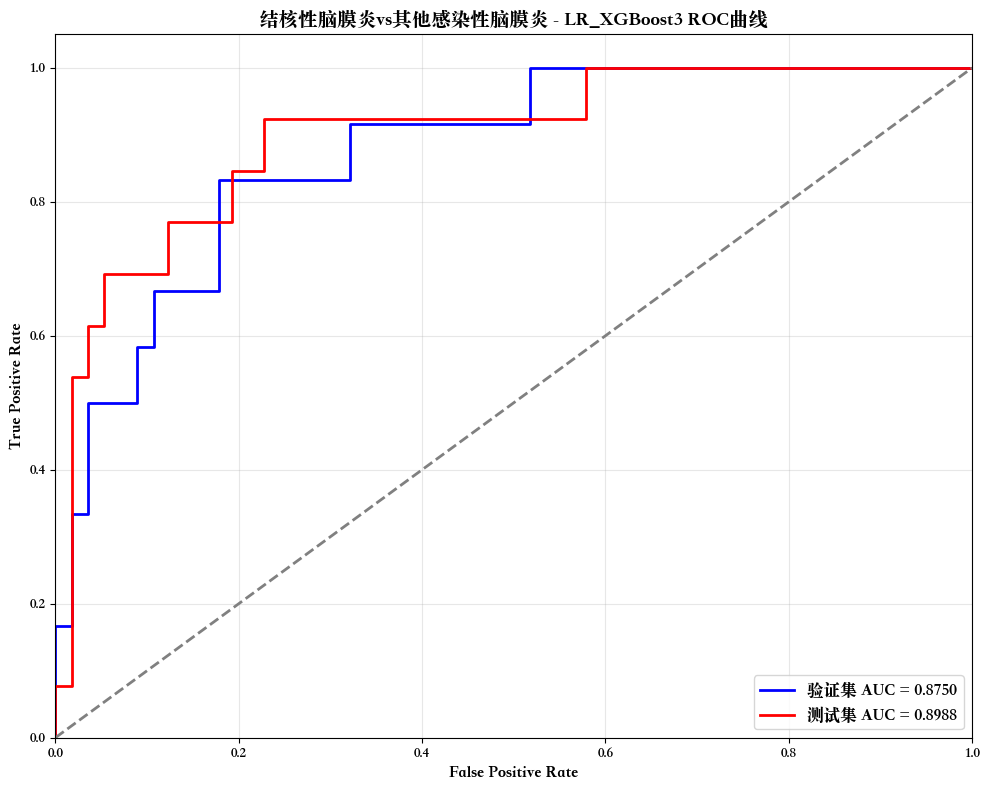

In [ ]:


screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    '感染性脑膜炎v非感染组': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

def delete_same_col(df):
    same_cols = df.nunique() == 1
    d = dict(same_cols)
    none_feature = []
    for keys, items in d.items():
        if items == True:
            none_feature.append(keys)
    return df.drop(none_feature, axis=1)


def run_model(key, item, selected_df, current_dataset):
    # 筛选需要的组别
    selected_df = selected_df[selected_df['分组'].isin(item[0])]

    # 删除数值一样的列
    selected_df = delete_same_col(selected_df)


    # 选择特征 将数据正例和反例平均分配
    filter_1 = selected_df[selected_df["分组"].isin(item[1])]
    filter_2 = selected_df[selected_df["分组"].isin(item[2])]
    
    X_1 = filter_1[list(filter_1.columns)[:-2]]
    X_2 = filter_2[list(filter_2.columns)[:-2]]

    # 标签（分组，1 类与其他类）
    y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
    y_2 = (filter_2['分组'].isin(item[1])).astype(int) 

    # 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
    X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
    X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

    X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
    X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

    # 将正例与反例拼接
    X_train = pd.concat([X_train_1,X_train_2])
    y_train = pd.concat([y_train_1,y_train_2])

    X_val = pd.concat([X_val_1,X_val_2])
    y_val = pd.concat([y_val_1,y_val_2])

    X_test = pd.concat([X_test_1,X_test_2])
    y_test = pd.concat([y_test_1,y_test_2])

    # 得到最优模型
    final_model = tain_model(X_train, y_train, X_val, y_val, key)

    # # 评估验证集和测试集
    val_results = evaluate_model(final_model, X_val, y_val, "验证", key)
    test_results = evaluate_model(final_model, X_test, y_test, "测试", key)    

    # 绘制ROC——AUC图 并存储数据
    draw_result(y_val, y_test, val_results, test_results, key, current_dataset)

    return test_results

    
if extract_integers(data_path)[-1] == 2:
    # print(filtered_df.columns)
    selected_features = {
        '阴性组vs其他': filtered_df[['脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量','血_嗜酸性粒细胞百分比_定量','血_葡萄糖空腹_定量','血_结核感染T细胞检测_定性','血_乙型肝炎病毒核心抗体.IgM_定量', '分组', '组名']],
        '感染性脑膜炎v非感染组': filtered_df[['脑脊液_单个核细胞百分比_定量','脑脊液_葡萄糖_定量', '脑脊液_激活淋巴细胞_定量','脑脊液_多个核细胞百分比_定量', '分组', '组名']],
        '细菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞.CD3+CD8+百分比_定量','分组', '组名']],
        '病毒性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_葡萄糖_定量','脑脊液_中性粒细胞百分比_定量','血_肌酸激酶_定量', '血_肾小球滤过率_定量', '血_免疫球蛋白E_定量','血_细胞.CD3-CD16+CD56+百分比_定量','脑脊液_多个核细胞百分比_定量','脑脊液_蛋白定量_定量','分组', '组名']],
        '结核性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_结核感染T细胞检测_定性','脑脊液_氯_定量','血_结核感染T细胞测试管_定量','脑脊液_葡萄糖_定量','血_淋巴细胞计数_定量','血_血小板分布宽度_定量', '血_铁蛋白_定量', '血_游离T4_定量', '分组', '组名']],
        '真菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_细胞.CD3-CD19+百分比_定量','血_不规则抗体_定性','血_梅毒非特异性抗体_定性', '脑脊液_有核细胞计数_定量', '分组', '组名']],
        '肿瘤性脑膜炎vs其他': filtered_df[['脑脊液_蛋白定量_定量', '脑脊液_葡萄糖_定量', '脑脊液_多个核细胞百分比_定量', '脑脊液_淋巴细胞百分比_定量', 'age','分组', '组名']],
        '自身免疫性脑膜炎vs其他': filtered_df[['血_丙型肝炎病毒抗体_定量','脑脊液_葡萄糖_定量','血_结核感染T细胞测试管_定量','血_铁蛋白_定量','脑脊液_蛋白定量_定量','血_D-二聚体_定量','血_乙型肝炎病毒核心抗体.IgM_定量','age','分组', '组名']],
        '病毒性脑膜炎vs病毒性脑炎': filtered_df[['脑脊液_有核细胞计数_定量','血_降钙素原_定量','血_同型半胱氨酸_定量','血_细胞.CD3+CD4+百分比_定量','血_血小板分布宽度_定量', '血_细胞.CD3+CD8+百分比_定量', '血_前白蛋白_定量', '血_铁蛋白_定量', '分组', '组名']]
    }

current_dataset = extract_integers(data_path)[-1]
finish = 0
for key, item in screen_data.items():
    # 训练模型 - 数据集1-8
    
    filtered_df2 = filtered_df.copy()
    result_para = run_model(key, item, filtered_df2, current_dataset)

    # 训练模型 - 精选特征数据集
    if current_dataset == 2:
        run_model(key, item, selected_features[key], 9)

     
        

In [ ]:
'''
filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})
# filtered_df = filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞.CD3+CD8+百分比_定量','分组', '组名']]
screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    # '感染性脑膜炎v非感染组': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    # '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    # '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    # '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    # '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    # '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    # '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    # '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

item = []
for key, item1 in screen_data.items():
    item = item1
print(item)

selected_df = filtered_df[filtered_df['分组'].isin(item[0])]

# 选择特征 将数据正例和反例平均分配
filter_1 = selected_df[selected_df["分组"].isin(item[1])]
filter_2 = selected_df[selected_df["分组"].isin(item[2])]

X_1 = filter_1[list(filter_1.columns)[2:-2]]
X_2 = filter_2[list(filter_2.columns)[2:-2]]
# print(X_1.columns)
# 标签（分组，1 类与其他类）
y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
y_2 = (filter_2['分组'].isin(item[1])).astype(int) 


# 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

# 将正例与反例拼接
X_train = pd.concat([X_train_1,X_train_2])
y_train = pd.concat([y_train_1,y_train_2])

X_val = pd.concat([X_val_1,X_val_2])
y_val = pd.concat([y_val_1,y_val_2])

X_test = pd.concat([X_test_1,X_test_2])
y_test = pd.concat([y_test_1,y_test_2])

'''


'\nfiltered_df = label_encoding(filtered_df, data_path)\n# 对 DataFrame 的列名进行清洗\nfiltered_df.columns = clean_feature_names_simple(filtered_df.columns)\n\n# 数据预处理：将 \'gender\' 列转换为数值型\nfiltered_df[\'gender\'] = filtered_df[\'gender\'].map({\'女\': 0, \'男\': 1})\n# filtered_df = filtered_df[[\'脑脊液_多个核细胞百分比_定量\',\'血_C反应蛋白_定量\',\'脑脊液_有核细胞计数_定量\',\'血_抗凝血酶III_定量\',\'血_血小板分布宽度_定量\',\'血_单核细胞计数_定量\', \'血_细胞.CD3+CD8+百分比_定量\',\'分组\', \'组名\']]\nscreen_data = {\n    \'阴性组vs其他\':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],\n    # \'感染性脑膜炎v非感染组\': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],\n    # \'细菌性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [1],  [2,3,4]],\n    # \'病毒性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [2], [1,3,4]],\n    # \'结核性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [3], [1,2,4]],\n    # \'真菌性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [4], [1,2,3]],\n    # \'肿瘤性脑膜炎vs其他\': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],\n    # \'自身免疫性脑膜炎vs其他\': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],\n    # \'病毒性脑膜炎vs病毒性脑炎\': [[2,8], [2], [8]]\n    }\n\nitem = []\nfor key, item1 in 

In [ ]:
'''


# params = {
#     'n_estimators': 1000,
#     'max_depth': 10,
#     'learning_rate': 0.0010217263561859077,
#     'subsample': 0.765745015802337,
#     'colsample_bytree': 0.7206332428817546,
#     'reg_alpha': 7.571565639799907e-07,
#     'reg_lambda':  0.007669065286362127,
#     'min_child_weight': 1,
#     'gamma': 0.028423560884985488,
#     'random_state': 42,
#     'use_label_encoder': False,
#     'eval_metric': 'logloss'   # 指定损失函数
# }
result_para['n_estimators'] = 140
# result_para['use_label_encoder'] = False
# result_para['eval_metric'] = 'logloss'
# result_para['random_state'] = 42
# params = {
#     'n_estimators': 500,
#     'max_depth': 3,
#     'learning_rate': 0.014423244028784152,
#     'subsample': 0.9003002169351246,
#     'colsample_bytree': 0.8158764226043772,
#     'reg_alpha': 0.043594962064358575,
#     'reg_lambda':  0.4046273356274994,
#     'min_child_weight': 2,
#     'gamma': 0.24895493093075793,
#     'random_state': 42,
#     'use_label_encoder': False,
#     'eval_metric': 'logloss'   # 指定损失函数
# }


model = xgb.XGBClassifier(**result_para)
# evals_result = {}
# 训练模型
model.fit(X_train, y_train,eval_set=[(X_train, y_train), (X_val, y_val)],  # 加入验证集
    # eval_metric="logloss",
    verbose=False,
    # evals_result=evals_result
)
evals_result = model.evals_result()

train_logloss = evals_result['validation_0']['logloss']
val_logloss = evals_result['validation_1']['logloss']

val_results = evaluate_model(model, X_val, y_val, "验证", "阴性组")   
test_results = evaluate_model(model, X_test, y_test, "测试", "阴性组")   
 
# print(test_results['auc'])
# 绘制曲线
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_logloss) + 1), train_logloss, label='Train Logloss')
plt.plot(range(1, len(val_logloss) + 1), val_logloss, label='Validation Logloss')
plt.xlabel('轮数')
plt.ylabel('损失')
plt.title(f'{list(screen_data.keys())[0]}损失曲线（拟合情况）')
plt.legend()
plt.show()

'''